In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = "/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET"

In [ ]:
files = os.listdir("/content/drive/MyDrive/BATTERY_SOC_PROJECT/SOC DATA SET/Dataset_Li-ion")
print(files)

['utils.py', 'Readme file - Description of Experimental Tests.txt', 'Technical Information and Experimental Test Results for LG 18650HG2.pdf', '10degC', '0degC', '25degC', '40degC', 'n10degC', 'n20degC']


In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/BATTERY_SOC_PROJECT"
DAY13_PATH = os.path.join(PROJECT_PATH, "day13_outputs")
DAY15_PATH = os.path.join(PROJECT_PATH, "day15_outputs")
os.makedirs(DAY15_PATH, exist_ok=True)

In [ ]:
def find_file(filename):
    for root, dirs, files in os.walk(PROJECT_PATH):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(
        f"Could not find: {filename} inside {PROJECT_PATH}")
soc_train_path = find_file("SOC_train_engineered_day13.csv")
soc_val_path = find_file("SOC_validation_engineered_day13.csv")
soc_test_path = find_file("SOC_test_engineered_day13.csv")
time_train_path = find_file("remaining_time_train_engineered_day13.csv")
time_val_path = find_file("remaining_time_validation_engineered_day13.csv")
time_test_path = find_file("remaining_time_test_engineered_day13.csv")
feature_file = find_file("final_feature_list_day13.json")
soc_train = pd.read_csv(soc_train_path)
soc_val = pd.read_csv(soc_val_path)
soc_test = pd.read_csv(soc_test_path)
time_train = pd.read_csv(time_train_path)
time_val = pd.read_csv(time_val_path)
time_test = pd.read_csv(time_test_path)
DAY13_PATH = os.path.dirname(feature_file)

print("Day 13 datasets loaded successfully.")
print("\nSOC datasets:")
print("Train:", soc_train.shape)
print("Validation:", soc_val.shape)
print("Test:", soc_test.shape)
print("\nRemaining Charging Time datasets:")
print("Train:", time_train.shape)
print("Validation:", time_val.shape)
print("Test:", time_test.shape)

Day 13 datasets loaded successfully.

SOC datasets:
Train: (9926, 10)
Validation: (7376, 10)
Test: (2250, 10)

Remaining Charging Time datasets:
Train: (41015, 11)
Validation: (1349, 11)
Test: (2286, 11)


In [ ]:
with open(feature_file, "r") as f:
    feature_data = json.load(f)
print("\nFinal feature list loaded.")
if isinstance(feature_data, list):
    features = feature_data
elif isinstance(feature_data, dict):
    if "features" in feature_data:
        features = feature_data["features"]
    elif "final_features" in feature_data:
        features = feature_data["final_features"]
    elif "selected_features" in feature_data:
        features = feature_data["selected_features"]
    else:
        features = []
else:
    features = []
if not features:
    excluded_columns = {
        "SOC",
        "Remaining Charging Time",
        "Source_File",
        "Charging_Session"}
    features = [
        col for col in soc_train.columns
        if col not in excluded_columns
        and pd.api.types.is_numeric_dtype(soc_train[col])
    ]
all_dataframes = [
    soc_train,
    soc_val,
    soc_test,
    time_train,
    time_val,
    time_test
]
features = [
    feature
    for feature in features
    if all(feature in data.columns for data in all_dataframes)
]
print("\nFeatures used for baseline modelling:")
print(features)


Final feature list loaded.

Features used for baseline modelling:
['Voltage', 'Current', 'Temperature', 'Elapsed Time', 'Cycle', 'WhAccu', 'Power']


In [ ]:
SOC_TARGET = "SOC"
TIME_TARGET = "Remaining Charging Time"
print("SOC data prepared using the Day 13 frozen split.")

SOC data prepared using the Day 13 frozen split.


In [ ]:
X_soc_train = soc_train[features].copy()
X_soc_val = soc_val[features].copy()
X_soc_test = soc_test[features].copy()
y_soc_train = soc_train[SOC_TARGET].copy()
y_soc_val = soc_val[SOC_TARGET].copy()
y_soc_test = soc_test[SOC_TARGET].copy()
print(" Remaining Charging Time data prepared.")

 Remaining Charging Time data prepared.


In [ ]:
X_time_train = time_train[features].copy()
X_time_val = time_val[features].copy()
X_time_test = time_test[features].copy()
y_time_train = time_train[TIME_TARGET].copy()
y_time_val = time_val[TIME_TARGET].copy()
y_time_test = time_test[TIME_TARGET].copy()
print(" Missing values handled using training-set medians.")

 Missing values handled using training-set medians.


In [ ]:
for feature in features:
    median_soc = X_soc_train[feature].median()
    X_soc_train[feature] = X_soc_train[feature].fillna(median_soc)
    X_soc_val[feature] = X_soc_val[feature].fillna(median_soc)
    X_soc_test[feature] = X_soc_test[feature].fillna(median_soc)
    median_time = X_time_train[feature].median()
    X_time_train[feature] = X_time_train[feature].fillna(median_time)
    X_time_val[feature] = X_time_val[feature].fillna(median_time)
    X_time_test[feature] = X_time_test[feature].fillna(median_time)

print("SOC Linear Regression baseline trained.")

SOC Linear Regression baseline trained.


In [ ]:
soc_model = LinearRegression()
soc_model.fit(X_soc_train,y_soc_train)
print("SOC Linear Regression model trained.")

SOC Linear Regression model trained.


In [ ]:
time_model = LinearRegression()
time_model.fit(X_time_train,y_time_train)
print("Remaining Charging Time Linear Regression model trained.")

Remaining Charging Time Linear Regression model trained.


In [ ]:
soc_train_pred = soc_model.predict(X_soc_train)
soc_val_pred = soc_model.predict(X_soc_val)
soc_test_pred = soc_model.predict(X_soc_test)
print("SOC predictions generated for train, validation and test sets.")

SOC predictions generated for train, validation and test sets.


In [ ]:
time_train_pred = time_model.predict(X_time_train)
time_val_pred = time_model.predict(X_time_val)
time_test_pred = time_model.predict(X_time_test)
print("Remaining Charging Time predictions generated.")

Remaining Charging Time predictions generated.


In [ ]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2
print("Evaluation metrics function applied.")

Evaluation metrics function applied.


In [ ]:
soc_train_metrics = calculate_metrics(y_soc_train, soc_train_pred)
soc_val_metrics = calculate_metrics(y_soc_val, soc_val_pred)
soc_test_metrics = calculate_metrics(y_soc_test, soc_test_pred)
print("SOC MAE, RMSE and R² calculated.")

SOC MAE, RMSE and R² calculated.


In [ ]:
time_train_metrics = calculate_metrics(y_time_train, time_train_pred)
time_val_metrics = calculate_metrics(y_time_val, time_val_pred)
time_test_metrics = calculate_metrics(y_time_test, time_test_pred)
print("Remaining Charging Time MAE, RMSE and R² calculated.")

Remaining Charging Time MAE, RMSE and R² calculated.


In [ ]:
results = pd.DataFrame([
    ["SOC", "Train", soc_train_metrics[0],
     soc_train_metrics[1], soc_train_metrics[2]],
    ["SOC", "Validation", soc_val_metrics[0],
     soc_val_metrics[1], soc_val_metrics[2]],
    ["SOC", "Test", soc_test_metrics[0],
     soc_test_metrics[1], soc_test_metrics[2]],
    ["Remaining Charging Time", "Train",
     time_train_metrics[0],
     time_train_metrics[1],
     time_train_metrics[2]],
    ["Remaining Charging Time", "Validation",
     time_val_metrics[0],
     time_val_metrics[1],
     time_val_metrics[2]],
    ["Remaining Charging Time", "Test",
     time_test_metrics[0],
     time_test_metrics[1],
     time_test_metrics[2]]
], columns=[
    "Target",
    "Dataset",
    "MAE",
    "RMSE",
    "R2"
])
print("\n----- BASELINE RESULTS ------\n")
print(results.to_string(index=False))


----- BASELINE RESULTS ------

                 Target    Dataset         MAE         RMSE        R2
                    SOC      Train    4.394107     9.180008  0.952339
                    SOC Validation   15.707497    21.039165  0.317793
                    SOC       Test    4.681095    11.754876  0.918719
Remaining Charging Time      Train 5011.746531  8046.066082  0.627244
Remaining Charging Time Validation 3274.076803  3667.171231 -5.459444
Remaining Charging Time       Test 8817.875379 12224.276890  0.709272


In [ ]:
results_path = os.path.join(DAY15_PATH,"day15_baseline_results.csv")
results.to_csv(results_path,index=False)
print("Baseline results saved successfully.")

Baseline results saved successfully.


In [ ]:
soc_predictions = pd.DataFrame({
    "Actual_SOC": y_soc_test.values,
    "Predicted_SOC": soc_test_pred})
soc_predictions.to_csv(
    os.path.join(DAY15_PATH,"SOC_baseline_test_predictions.csv"),index=False)
print("SOC test-set prediction results saved.")


SOC test-set prediction results saved.


In [ ]:
time_predictions = pd.DataFrame({"Actual_Remaining_Charging_Time": y_time_test.values,"Predicted_Remaining_Charging_Time": time_test_pred})
time_predictions.to_csv(
    os.path.join(DAY15_PATH,"Remaining_Time_baseline_test_predictions.csv"),index=False)
print("Remaining Charging Time test-set predictions saved.")

Remaining Charging Time test-set predictions saved.


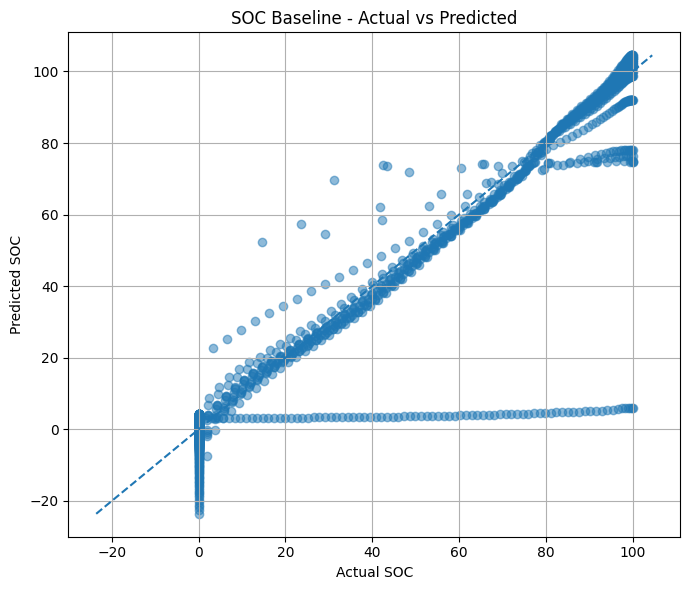

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_soc_test,soc_test_pred,alpha=0.5)
minimum = min(y_soc_test.min(),soc_test_pred.min())
maximum = max(y_soc_test.max(),soc_test_pred.max())
plt.plot([minimum, maximum],[minimum, maximum],linestyle="--")
plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("SOC Baseline - Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(DAY15_PATH,"SOC_actual_vs_predicted_baseline.png"),dpi=300)
plt.show()

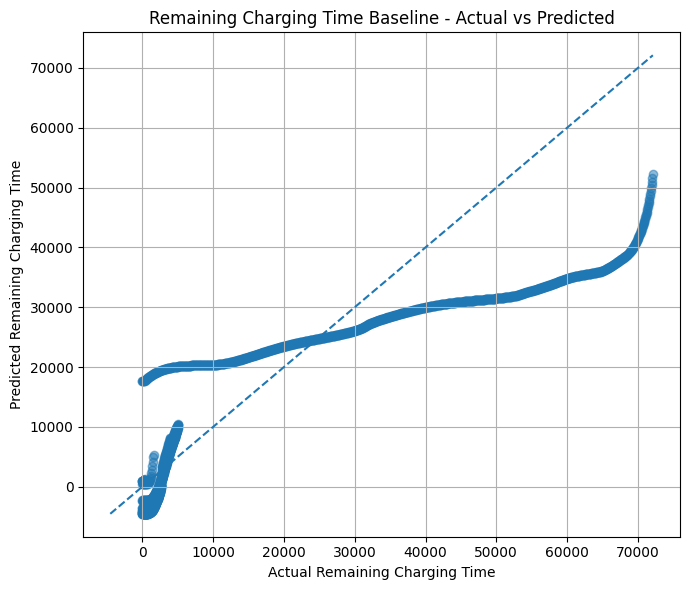

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_time_test,time_test_pred,alpha=0.5)
minimum = min(y_time_test.min(),time_test_pred.min())
maximum = max(y_time_test.max(),time_test_pred.max())
plt.plot([minimum, maximum],[minimum, maximum],linestyle="--")
plt.xlabel("Actual Remaining Charging Time")
plt.ylabel("Predicted Remaining Charging Time")
plt.title("Remaining Charging Time Baseline - Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(DAY15_PATH,"Remaining_Time_actual_vs_predicted_baseline.png"),dpi=300)
plt.show()

In [ ]:
joblib.dump(
    soc_model,
    os.path.join(DAY15_PATH,"SOC_linear_regression_baseline_day15.joblib"))
joblib.dump(
    time_model,
    os.path.join(
        DAY15_PATH,"Remaining_Time_linear_regression_baseline_day15.joblib"))

['/content/drive/MyDrive/BATTERY_SOC_PROJECT/day15_outputs/Remaining_Time_linear_regression_baseline_day15.joblib']

In [ ]:
with open(
    os.path.join(DAY15_PATH,"day15_baseline_features.json"),"w") as f:
    json.dump(
        {
            "features_used": features,
            "targets": [SOC_TARGET,TIME_TARGET],
            "model": "Linear Regression",
            "split_source": "Day 13 frozen train/validation/test datasets"
        },
        f,
        indent=4
    )
    print("Baseline feature and target information saved.")

Baseline feature and target information saved.


In [ ]:
findings = """
Linear Regression was used as the baseline model for both SOC estimation
and Remaining Charging Time prediction.

The frozen train, validation and test datasets from Day 13 were used,
so no new data split was created.

MAE, RMSE and R2 were calculated for training, validation and test sets.

Actual versus predicted plots were generated using the test set.

The Linear Regression results will serve as the baseline reference for
evaluating more advanced machine learning models in subsequent days.

MODELLING DIRECTION
If the baseline performance is not sufficiently accurate, nonlinear
machine learning models will be evaluated and compared against this baseline.
"""
with open(
    os.path.join(
        DAY15_PATH,
        "day15_initial_findings.txt"
    ),
    "w"
) as f:
    f.write(findings)
    print("Initial findings and modelling direction recorded.")

Initial findings and modelling direction recorded.


In [ ]:
print("\nSaved files:")
for filename in sorted(os.listdir(DAY15_PATH)):
    print("", filename)


Saved files:
 Remaining_Time_actual_vs_predicted_baseline.png
 Remaining_Time_baseline_test_predictions.csv
 Remaining_Time_linear_regression_baseline_day15.joblib
 SOC_actual_vs_predicted_baseline.png
 SOC_baseline_test_predictions.csv
 SOC_linear_regression_baseline_day15.joblib
 day15_baseline_features.json
 day15_baseline_results.csv
 day15_initial_findings.txt
